In [ ]:
# Add project folder to sys.path
import sys
from pathlib import Path
project_path = Path(r"add-your-file-path\student-success-predictor")
sys.path.append(str(project_path))

In [184]:
from data_pre_processing.utils.data_cleaner import DataCleaner
from skimpy import skim
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

In [185]:
# ------- Validation ranges ------------
valid_ranges = {
    # continuous → min/max
    "first_term_gpa": {"type": "range", "min": 0.0, "max": 4.5},
    "second_term_gpa": {"type": "range", "min": 0.0, "max": 4.5},
    "high_school_average_mark": {"type": "range", "min": 0, "max": 100},
    "math_score": {"type": "range", "min": 0, "max": 50},

    # categorical → exact values
    "first_language": {"type": "values", "values": [1, 2, 3]},
    "funding": {"type": "values", "values": list(range(1, 10))},
    "fast_track": {"type": "values", "values": [1, 2]},
    "coop": {"type": "values", "values": [1, 2]},
    "residency": {"type": "values", "values": [1, 2]},
    "gender": {"type": "values", "values": [1, 2, 3]},
    "previous_education": {"type": "values", "values": [1, 2]},
    "age_group": {"type": "values", "values": list(range(1, 11))},
    "english_grade": {"type": "values", "values": list(range(1, 12))},
    "first_year_persistence": {"type": "values", "values": [0, 1]}
}


In [186]:
# ---------- Helper functions ----------
def validate_column(ranges, df):
    """ validate columns based on provided rules and return a summary DataFrame """
    summary = []
    for col, rule in ranges.items():
        series = df[col]
        total = len(series)
        missing_count = series.isna().sum()

        if rule["type"] == "range":
            valid_mask = series.between(rule["min"], rule["max"])
            allowed = f"{rule['min']}-{rule['max']}"
        else:
            valid_mask = series.isin(rule["values"])
            allowed = rule["values"]

        valid_count = valid_mask.sum()
        invalid_count = total - valid_count - missing_count

        summary.append({
            "Column": col,
            "Total Values": total,
            "Missing Count": missing_count,
            "Allowed": allowed,
            "Unique Count": series.nunique(dropna=True),
            "Unique Before Cleaning": sorted(series.dropna().unique().tolist())[:10],
            "Valid Count": valid_count,
            "Invalid Count": invalid_count
        })

    return pd.DataFrame(summary)

In [187]:
#--- Main code ---
np.random.seed(42)

# Load the structured dataset
structured_data_file = project_path / "data/structured_student_data.csv"
structured_df = pd.read_csv(structured_data_file)

# Observe the dataset
skim(structured_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1437   │ │ string      │ 8     │                                                          │
│ │ Number of columns │ 15     │ │ float64     │ 7     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                    ┃ NA  ┃ NA %   ┃ mean     ┃ sd       ┃ p0  ┃ p25  ┃ p50  ┃ p75  ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ funding                   │   0 │      0 │    2.927 │    1.258 │   1 │    2 │    2 │    4 │     9 │  ▇ ▆   │  │
│ │ school                    │   0 │      0 │        6 │        0 │   6 │    6 │    6 │    6 │     6 │     ▇  │  │
│ │ fast_track                │   0 │      0 │    1.742 │   0.4378 │   1 │    1 │    2 │    2 │     2 │ ▃    ▇ │  │
│ │ coop                      │   0 │      0 │    1.695 │   0.4605 │   1 │    1 │    2 │    2 │     2 │ ▃    ▇ │  │
│ │ residency                 │   0 │      0 │    1.406 │   0.4913 │   1 │    1 │    1 │    2 │     2 │ ▇    ▅ │  │
│ │ gender                    │   0 │      0 │    1.775 │   0.4197 │   1 │    2 │    2 │    2 │     3 │  ▂  ▇  │  │
│ │ first_year_persistence    │   0 │      0 │   0.7919 │   0.4061 │   0 │    1 │    1 │    1 │     1 │ ▂    ▇ │  │
│ └───────────────────────────┴─────┴────────┴──────────┴──────────┴─────┴──────┴──────┴──────┴───────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓  │
│ ┃ column         ┃ NA ┃ NA % ┃ shortest ┃ longest  ┃ min ┃ max ┃ chars per row ┃ words per row ┃ total words ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩  │
│ │ first_term_gpa │  0 │    0 │ 0        │ 3.020833 │ 0   │ ?   │          6.16 │             1 │        1437 │  │
│ │ second_term_gp │  0 │    0 │ 0        │ 3.923077 │ 0   │ ?   │          5.81 │             1 │        1437 │  │
│ │ a              │    │      │          │          │     │     │               │               │             │  │
│ │ first_language │  0 │    0 │ 1        │ 1        │ 1   │ ?   │             1 │             1 │        1437 │  │
│ │ previous_educa │  0 │    0 │ 1        │ 1        │ 0   │ ?   │             1 │             1 │        1437 │  │
│ │ tion           │    │      │          │          │     │     │               │               │             │  │
│ │ age_group      │  0 │    0 │ 1        │ 1        │ 1   │ ?   │             1 │             1 │        1437 │  │
│ │ high_school_av │  0 │    0 │ ?        │ 101      │ 100 │ ?   │          1.49 │             1 │        1437 │  │
│ │ erage_mark     │    │      │          │          │     │     │               │               │             │  │
│ │ math_score     │  0 │    0 │ ?        │ 16       │ 10  │ ?   │          1.68 │             1 │        1437 │  │
│ │ english_grade  │  0 │    0 │ 7        │ 10       │ 1

In [188]:
# Replace ? with NaN and drop duplicates
print("Number of duplicates before cleaning:", structured_df.duplicated().sum())
clean_df = structured_df.replace("?", np.nan).apply(pd.to_numeric, errors="coerce").drop_duplicates()
skim(clean_df)

Number of duplicates before cleaning: 1


╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1436   │ │ float64     │ 15    │                                                          │
│ │ Number of columns │ 15     │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━┓  │
│ ┃ column             ┃ NA  ┃ NA %              ┃ mean   ┃ sd     ┃ p0 ┃ p25  ┃ p50   ┃ p75   ┃ p100 ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━┩  │
│ │ first_term_gpa     │  17 │ 1.183844011142061 │  2.848 │  1.173 │  0 │ 2.25 │ 3.105 │ 3.739 │  4.5 │ ▂▁▃▆▇▇ │  │
│ │                    │     │                 4 │        │        │    │      │       │       │      │        │  │
│ │ second_term_gpa    │ 159 │ 11.07242339832869 │   2.82 │  1.129 │  0 │ 2.26 │ 3.028 │  3.68 │  4.5 │ ▂▁▃▆▇▆ │  │
│ │                    │     │                 1 │        │        │    │      │       │       │      │        │  │
│ │ first_language     │ 111 │ 7.729805013927576 │   1.91 │ 0.9948 │  1 │    1 │     1 │     3 │    3 │ ▇    ▇ │  │
│ │ funding            │   0 │                 0 │  2.926 │  1.258 │  1 │    2 │     2 │     4 │    9 │  ▇ ▆   │  │
│ │ school             │   0 │                 0 │      6 │      0 │  6 │    6 │     6 │     6 │    6 │     ▇  │  │
│ │ fast_track         │   0 │                 0 │  1.742 │ 0.4375 │  1 │    1 │     2 │     2 │    2 │ ▃    ▇ │  │
│ │ coop               │   0 │                 0 │  1.695 │ 0.4606 │  1 │    1 │     2 │     2 │    2 │ ▃    ▇ │  │
│ │ residency          │   0 │                 0 │  1.406 │ 0.4913 │  1 │    1 │     1 │     2 │    2 │ ▇    ▅ │  │
│ │ gender             │   0 │                 0 │  1.774 │ 0.4198 │  1 │    2 │     2 │     2 │    3 │  ▂  ▇  │  │
│ │ previous_education │   4 │ 0.278551532033426 │  1.275 │  0.568 │  0 │    1 │     1 │     2 │    2 │ ▁  ▇ ▅ │  │
│ │                    │     │                 2 │        │        │    │      │       │       │      │        │  │
│ │ age_group          │   4 │ 0.278551532033426 │  2.631 │  1.422 │  1 │    2 │     3 │     3 │    8 │ ▇▇▁▁ ▁ │  │
│ │                    │     │                 2 │        │        │    │      │       │       │      │        │  │
│ │ high_school_averag │ 742 │ 51.67130919220056 │  77.15 │  12.07 │ 17 │   70 │  77.5 │    85 │  108 │   ▂▇▇▂ │  │
│ │ e_mark             │     │                   │        │        │    │      │       │       │      │        │  │
│ │ math_score         │ 461 │ 32.10306406685237 │  32.56 │  10.71 │  6 │   23 │    32 │    43 │   50 │ ▁▅▇▇▅▇ │  │
│ │ english_grade      │  45 │ 3.133704735376044 │   8.03 │  1.717 │  1 │    7 │     8 │     9 │   10 │   ▁ ▇▇ │  │
│ │                    │     │                 8 │        │        │    │      │       │       │      │        │  │
│ │ first_year_persist │   0 │                 0 │ 0.7925 │ 0.4057 │  0 │    1 │     1 │     1 │    1 │ ▂    ▇ │  │
│ │ ence               │     │                   │        │        │    │      │       │       │      │        │  │
│ └────────────────────┴─────┴───────────────────┴──────

In [189]:
validate_columns = validate_column(valid_ranges, clean_df)
print("Validation summary before cleaning:")
display(validate_columns)

Validation summary before cleaning:


,Column,Total Values,Missing Count,Allowed,Unique Count,Unique Before Cleaning,Valid Count,Invalid Count
0,first_term_gpa,1436,17,0.0-4.5,692,"[0.0, 0.142857, 0.157895, 0.176471, 0.18, 0.2,...",1419,0
1,second_term_gpa,1436,159,0.0-4.5,717,"[0.0, 0.136364, 0.157895, 0.25, 0.266667, 0.3,...",1277,0
2,high_school_average_mark,1436,742,0-100,64,"[17.0, 25.0, 42.0, 44.0, 45.0, 48.0, 50.0, 51....",681,13
3,math_score,1436,461,0-50,43,"[6.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0,...",975,0
4,first_language,1436,111,"[1, 2, 3]",3,"[1.0, 2.0, 3.0]",1325,0
5,funding,1436,0,"[1, 2, 3, 4, 5, 6, 7, 8, 9]",6,"[1.0, 2.0, 4.0, 5.0, 8.0, 9.0]",1436,0
6,fast_track,1436,0,"[1, 2]",2,"[1.0, 2.0]",1436,0
7,coop,1436,0,"[1, 2]",2,"[1.0, 2.0]",1436,0
8,residency,1436,0,"[1, 2]",2,"[1.0, 2.0]",1436,0
9,gender,1436,0,"[1, 2, 3]",3,"[1.0, 2.0, 3.0]",1436,0


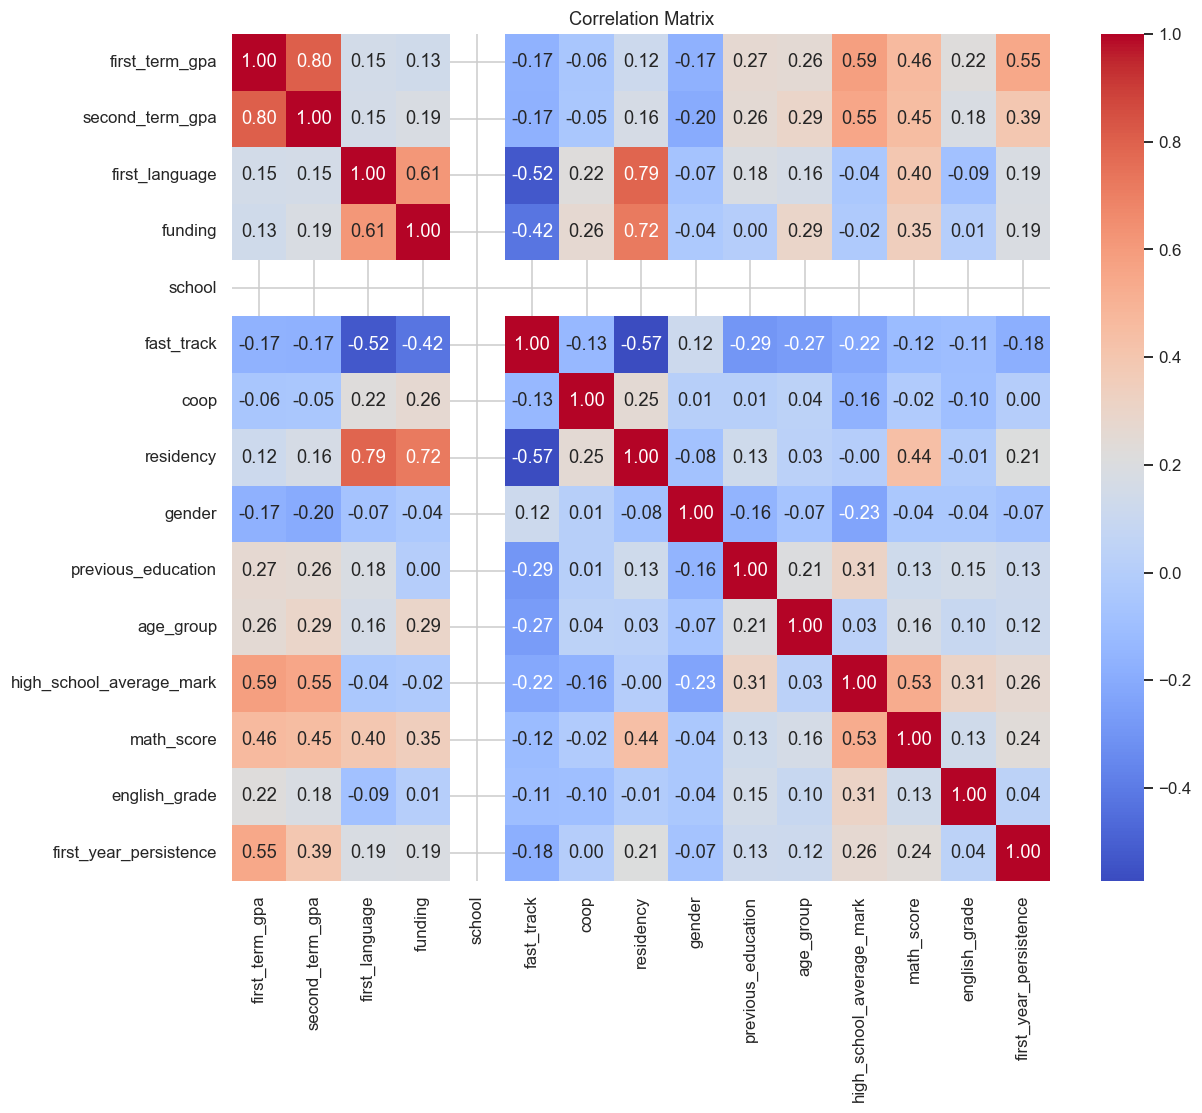

In [190]:
# correlation matrix
correlation_matrix = clean_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix") 
plt.show()

In [191]:
# drop non-informative column - school: only one unique value -6; coorrelation with target variable is non-existent
clean_df = clean_df.drop(columns=["school"])

In [192]:
# column categorization
numeric_cols = ["first_term_gpa", "second_term_gpa", "high_school_average_mark", "math_score"]
binary_cols = ["fast_track", "coop", "residency"]
nominal_cols = ["first_language", "funding", "gender", "previous_education"]
ordinal_cols = ["age_group", "english_grade"]
target_col = "first_year_persistence"

# check the dataset
display(clean_df.head())

,first_term_gpa,second_term_gpa,first_language,funding,fast_track,coop,residency,gender,previous_education,age_group,high_school_average_mark,math_score,english_grade,first_year_persistence
0,0.000000,0.000000,1.0,2.0,2.0,1.0,1.0,2.0,1.0,1.0,59.0,16.0,7.0,1.0
1,2.500000,2.000000,3.0,4.0,1.0,2.0,2.0,2.0,1.0,3.0,NaN,NaN,7.0,1.0
2,4.250000,3.923077,1.0,1.0,2.0,1.0,1.0,1.0,2.0,3.0,92.0,41.0,9.0,1.0
3,3.020833,2.321429,3.0,4.0,1.0,2.0,2.0,2.0,2.0,3.0,NaN,NaN,8.0,1.0
4,4.275000,4.326923,1.0,2.0,1.0,1.0,1.0,1.0,2.0,3.0,97.0,NaN,9.0,1.0


In [193]:
# fix high school average mark outliers
clean_df["high_school_average_mark"] = clean_df["high_school_average_mark"].clip(0, 100)

In [194]:
validate_columns = validate_column(valid_ranges, clean_df)
print("Validation summary after cleaning:")
display(validate_columns)

Validation summary after cleaning:


,Column,Total Values,Missing Count,Allowed,Unique Count,Unique Before Cleaning,Valid Count,Invalid Count
0,first_term_gpa,1436,17,0.0-4.5,692,"[0.0, 0.142857, 0.157895, 0.176471, 0.18, 0.2,...",1419,0
1,second_term_gpa,1436,159,0.0-4.5,717,"[0.0, 0.136364, 0.157895, 0.25, 0.266667, 0.3,...",1277,0
2,high_school_average_mark,1436,742,0-100,57,"[17.0, 25.0, 42.0, 44.0, 45.0, 48.0, 50.0, 51....",694,0
3,math_score,1436,461,0-50,43,"[6.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0,...",975,0
4,first_language,1436,111,"[1, 2, 3]",3,"[1.0, 2.0, 3.0]",1325,0
5,funding,1436,0,"[1, 2, 3, 4, 5, 6, 7, 8, 9]",6,"[1.0, 2.0, 4.0, 5.0, 8.0, 9.0]",1436,0
6,fast_track,1436,0,"[1, 2]",2,"[1.0, 2.0]",1436,0
7,coop,1436,0,"[1, 2]",2,"[1.0, 2.0]",1436,0
8,residency,1436,0,"[1, 2]",2,"[1.0, 2.0]",1436,0
9,gender,1436,0,"[1, 2, 3]",3,"[1.0, 2.0, 3.0]",1436,0


In [195]:
# Convert binary variables (1/2 -> 1/0)
for col in binary_cols:
    clean_df[col] = clean_df[col].map({1: 1, 2: 0})

In [196]:
missing_flag_cols = [
    "first_term_gpa",
    "second_term_gpa",
    "high_school_average_mark",
    "math_score",
    "first_language",
    "previous_education",
    "age_group",
    "english_grade",
]

for col in missing_flag_cols:
    clean_df[f"{col}_missing"] = clean_df[col].isna().astype(int)

# check the cleaned dataset
display(clean_df.head())

,first_term_gpa,second_term_gpa,first_language,funding,fast_track,coop,residency,gender,previous_education,age_group,...,english_grade,first_year_persistence,first_term_gpa_missing,second_term_gpa_missing,high_school_average_mark_missing,math_score_missing,first_language_missing,previous_education_missing,age_group_missing,english_grade_missing
0,0.000000,0.000000,1.0,2.0,0,1,1,2.0,1.0,1.0,...,7.0,1.0,0,0,0,0,0,0,0,0
1,2.500000,2.000000,3.0,4.0,1,0,0,2.0,1.0,3.0,...,7.0,1.0,0,0,1,1,0,0,0,0
2,4.250000,3.923077,1.0,1.0,0,1,1,1.0,2.0,3.0,...,9.0,1.0,0,0,0,0,0,0,0,0
3,3.020833,2.321429,3.0,4.0,1,0,0,2.0,2.0,3.0,...,8.0,1.0,0,0,1,1,0,0,0,0
4,4.275000,4.326923,1.0,2.0,1,1,1,1.0,2.0,3.0,...,9.0,1.0,0,0,0,1,0,0,0,0


In [197]:
# impute missing values with advanced techniques like IterativeImputer with RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer  # required
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

# # impute using random forest regressor for numeric columns
imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=50, random_state=42),
    max_iter=15,
    random_state=42
)

# # impute using Mice techique with BayesianRidge as the estimator
# from sklearn.linear_model import BayesianRidge
# imputer = IterativeImputer(
#     estimator=BayesianRidge(),
#     max_iter=15,
#     random_state=42
# )

imputed_array = imputer.fit_transform(clean_df[numeric_cols])
clean_df[numeric_cols] = imputed_array

# skim the dataset after imputation
skim(clean_df)


C:\Vivek\Soft\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1436   │ │ float64     │ 11    │                                                          │
│ │ Number of columns │ 22     │ │ int64       │ 11    │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━┓  │
│ ┃ column           ┃ NA  ┃ NA %            ┃ mean     ┃ sd      ┃ p0 ┃ p25   ┃ p50   ┃ p75   ┃ p100 ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━┩  │
│ │ first_term_gpa   │   0 │               0 │    2.841 │   1.171 │  0 │  2.23 │ 3.095 │ 3.739 │  4.5 │ ▂▁▃▆▇▇ │  │
│ │ second_term_gpa  │   0 │               0 │    2.659 │   1.216 │  0 │ 1.947 │ 2.886 │ 3.604 │  4.5 │ ▃▂▃▆▇▆ │  │
│ │ first_language   │ 111 │ 7.7298050139275 │     1.91 │  0.9948 │  1 │     1 │     1 │     3 │    3 │ ▇    ▇ │  │
│ │                  │     │              76 │          │         │    │       │       │       │      │        │  │
│ │ funding          │   0 │               0 │    2.926 │   1.258 │  1 │     2 │     2 │     4 │    9 │  ▇ ▆   │  │
│ │ fast_track       │   0 │               0 │   0.2577 │  0.4375 │  0 │     0 │     0 │     1 │    1 │ ▇    ▃ │  │
│ │ coop             │   0 │               0 │    0.305 │  0.4606 │  0 │     0 │     0 │     1 │    1 │ ▇    ▃ │  │
│ │ residency        │   0 │               0 │    0.594 │  0.4913 │  0 │     0 │     1 │     1 │    1 │ ▅    ▇ │  │
│ │ gender           │   0 │               0 │    1.774 │  0.4198 │  1 │     2 │     2 │     2 │    3 │  ▂  ▇  │  │
│ │ previous_educati │   4 │ 0.2785515320334 │    1.275 │   0.568 │  0 │     1 │     1 │     2 │    2 │ ▁  ▇ ▅ │  │
│ │ on               │     │             262 │          │         │    │       │       │       │      │        │  │
│ │ age_group        │   4 │ 0.2785515320334 │    2.631 │   1.422 │  1 │     2 │     3 │     3 │    8 │ ▇▇▁▁ ▁ │  │
│ │                  │     │             262 │          │         │    │       │       │       │      │        │  │
│ │ high_school_aver │   0 │               0 │     79.6 │   10.45 │ 17 │    74 │    80 │ 87.72 │  100 │   ▁▃▇▅ │  │
│ │ age_mark         │     │                 │          │         │    │       │       │       │      │        │  │
│ │ math_score       │   0 │               0 │    33.17 │   9.859 │  6 │ 25.31 │    33 │    42 │   50 │  ▃▇▇▇▇ │  │
│ │ english_grade    │  45 │ 3.1337047353760 │     8.03 │   1.717 │  1 │     7 │     8 │     9 │   10 │   ▁ ▇▇ │  │
│ │                  │     │             448 │          │         │    │       │       │       │      │        │  │
│ │ first_year_persi │   0 │               0 │   0.7925 │  0.4057 │  0 │     1 │     1 │     1 │    1 │ ▂    ▇ │  │
│ │ stence           │     │                 │          │         │    │       │       │       │      │        │  │
│ │ first_term_gpa_m │   0 │               0 │  0.01184 │  0.1082 │  0 │     0 │     0 │     0 │    1 │   ▇    │  │
│ │ issing           │     │                 │          │         │    │       │       │       │      │        │  │
│ │ second_term_gpa_ │   0 │               0 │   0.1107 

In [198]:
# impute ordinal columns with missing category (0)
for col in ordinal_cols:
    clean_df[col] = clean_df[col].fillna(0).astype(int)

# skim the dataset after imputation
skim(clean_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1436   │ │ int64       │ 13    │                                                          │
│ │ Number of columns │ 22     │ │ float64     │ 9     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━┓  │
│ ┃ column           ┃ NA  ┃ NA %            ┃ mean     ┃ sd      ┃ p0 ┃ p25   ┃ p50   ┃ p75   ┃ p100 ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━┩  │
│ │ first_term_gpa   │   0 │               0 │    2.841 │   1.171 │  0 │  2.23 │ 3.095 │ 3.739 │  4.5 │ ▂▁▃▆▇▇ │  │
│ │ second_term_gpa  │   0 │               0 │    2.659 │   1.216 │  0 │ 1.947 │ 2.886 │ 3.604 │  4.5 │ ▃▂▃▆▇▆ │  │
│ │ first_language   │ 111 │ 7.7298050139275 │     1.91 │  0.9948 │  1 │     1 │     1 │     3 │    3 │ ▇    ▇ │  │
│ │                  │     │              76 │          │         │    │       │       │       │      │        │  │
│ │ funding          │   0 │               0 │    2.926 │   1.258 │  1 │     2 │     2 │     4 │    9 │  ▇ ▆   │  │
│ │ fast_track       │   0 │               0 │   0.2577 │  0.4375 │  0 │     0 │     0 │     1 │    1 │ ▇    ▃ │  │
│ │ coop             │   0 │               0 │    0.305 │  0.4606 │  0 │     0 │     0 │     1 │    1 │ ▇    ▃ │  │
│ │ residency        │   0 │               0 │    0.594 │  0.4913 │  0 │     0 │     1 │     1 │    1 │ ▅    ▇ │  │
│ │ gender           │   0 │               0 │    1.774 │  0.4198 │  1 │     2 │     2 │     2 │    3 │  ▂  ▇  │  │
│ │ previous_educati │   4 │ 0.2785515320334 │    1.275 │   0.568 │  0 │     1 │     1 │     2 │    2 │ ▁  ▇ ▅ │  │
│ │ on               │     │             262 │          │         │    │       │       │       │      │        │  │
│ │ age_group        │   0 │               0 │    2.624 │   1.427 │  0 │     1 │     3 │     3 │    8 │ ▅▅▇▂ ▁ │  │
│ │ high_school_aver │   0 │               0 │     79.6 │   10.45 │ 17 │    74 │    80 │ 87.72 │  100 │   ▁▃▇▅ │  │
│ │ age_mark         │     │                 │          │         │    │       │       │       │      │        │  │
│ │ math_score       │   0 │               0 │    33.17 │   9.859 │  6 │ 25.31 │    33 │    42 │   50 │  ▃▇▇▇▇ │  │
│ │ english_grade    │   0 │               0 │    7.779 │   2.194 │  0 │     7 │     8 │     9 │   10 │ ▁ ▁ ▇▇ │  │
│ │ first_year_persi │   0 │               0 │   0.7925 │  0.4057 │  0 │     1 │     1 │     1 │    1 │ ▂    ▇ │  │
│ │ stence           │     │                 │          │         │    │       │       │       │      │        │  │
│ │ first_term_gpa_m │   0 │               0 │  0.01184 │  0.1082 │  0 │     0 │     0 │     0 │    1 │   ▇    │  │
│ │ issing           │     │                 │          │         │    │       │       │       │      │        │  │
│ │ second_term_gpa_ │   0 │               0 │   0.1107 │  0.3139 │  0 │     0 │     0 │     0 │    1 │ ▇    ▁ │  │
│ │ missing          │     │                 │          │         │    │       │       │       │      │        │  │
│ │ high_school_aver │   0 │               0 │   0.5167 

In [199]:
# impute first language with missing category (0)
clean_df["first_language"] = clean_df["first_language"].fillna(0).astype(int)

# impute previous education with missing category(3) and already have 0 which is unknown category, so use 3 for missing values
clean_df["previous_education"] = clean_df["previous_education"].fillna(3).astype(int)

# skim the dataset after imputation
skim(clean_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1436   │ │ int64       │ 15    │                                                          │
│ │ Number of columns │ 22     │ │ float64     │ 7     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━┓  │
│ ┃ column                 ┃ NA  ┃ NA %  ┃ mean      ┃ sd       ┃ p0  ┃ p25    ┃ p50   ┃ p75   ┃ p100 ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━┩  │
│ │ first_term_gpa         │   0 │     0 │     2.841 │    1.171 │   0 │   2.23 │ 3.095 │ 3.739 │  4.5 │ ▂▁▃▆▇▇ │  │
│ │ second_term_gpa        │   0 │     0 │     2.659 │    1.216 │   0 │  1.947 │ 2.886 │ 3.604 │  4.5 │ ▃▂▃▆▇▆ │  │
│ │ first_language         │   0 │     0 │     1.763 │    1.083 │   0 │      1 │     1 │     3 │    3 │ ▁ ▇  ▇ │  │
│ │ funding                │   0 │     0 │     2.926 │    1.258 │   1 │      2 │     2 │     4 │    9 │  ▇ ▆   │  │
│ │ fast_track             │   0 │     0 │    0.2577 │   0.4375 │   0 │      0 │     0 │     1 │    1 │ ▇    ▃ │  │
│ │ coop                   │   0 │     0 │     0.305 │   0.4606 │   0 │      0 │     0 │     1 │    1 │ ▇    ▃ │  │
│ │ residency              │   0 │     0 │     0.594 │   0.4913 │   0 │      0 │     1 │     1 │    1 │ ▅    ▇ │  │
│ │ gender                 │   0 │     0 │     1.774 │   0.4198 │   1 │      2 │     2 │     2 │    3 │  ▂  ▇  │  │
│ │ previous_education     │   0 │     0 │      1.28 │   0.5744 │   0 │      1 │     1 │     2 │    3 │ ▁ ▇ ▅  │  │
│ │ age_group              │   0 │     0 │     2.624 │    1.427 │   0 │      1 │     3 │     3 │    8 │ ▅▅▇▂ ▁ │  │
│ │ high_school_average_ma │   0 │     0 │      79.6 │    10.45 │  17 │     74 │    80 │ 87.72 │  100 │   ▁▃▇▅ │  │
│ │ rk                     │     │       │           │          │     │        │       │       │      │        │  │
│ │ math_score             │   0 │     0 │     33.17 │    9.859 │   6 │  25.31 │    33 │    42 │   50 │  ▃▇▇▇▇ │  │
│ │ english_grade          │   0 │     0 │     7.779 │    2.194 │   0 │      7 │     8 │     9 │   10 │ ▁ ▁ ▇▇ │  │
│ │ first_year_persistence │   0 │     0 │    0.7925 │   0.4057 │   0 │      1 │     1 │     1 │    1 │ ▂    ▇ │  │
│ │ first_term_gpa_missing │   0 │     0 │   0.01184 │   0.1082 │   0 │      0 │     0 │     0 │    1 │   ▇    │  │
│ │ second_term_gpa_missin │   0 │     0 │    0.1107 │   0.3139 │   0 │      0 │     0 │     0 │    1 │ ▇    ▁ │  │
│ │ g                      │     │       │           │          │     │        │       │       │      │        │  │
│ │ high_school_average_ma │   0 │     0 │    0.5167 │   0.4999 │   0 │      0 │     1 │     1 │    1 │ ▇    ▇ │  │
│ │ rk_missing             │     │       │           │          │     │        │       │       │      │        │  │
│ │ math_score_missing     │   0 │     0 │     0.321 │    0.467 │   0 │      0 │     0 │     1 │    1 │ ▇    ▃ │  │
│ │ first_language_missing │   0 │     0 │    0.0773 │   0.2672 │   0 │      0 │     0 │     0 │    1 │ ▇    ▁ │  │
│ │ previous_education_mis │   0 │     0 │  0.002786 │  

In [200]:
# validate coded values after cleaning
values_summary_df_after = validate_column(valid_ranges, clean_df)
print("Validation summary after cleaning:")
display(values_summary_df_after)

Validation summary after cleaning:


,Column,Total Values,Missing Count,Allowed,Unique Count,Unique Before Cleaning,Valid Count,Invalid Count
0,first_term_gpa,1436,0,0.0-4.5,709,"[0.0, 0.142857, 0.157895, 0.176471, 0.18, 0.2,...",1436,0
1,second_term_gpa,1436,0,0.0-4.5,850,"[0.0, 0.03381579999999999, 0.039, 0.055, 0.061...",1436,0
2,high_school_average_mark,1436,0,0-100,597,"[17.0, 25.0, 42.0, 44.0, 45.0, 48.0, 50.0, 51....",1436,0
3,math_score,1436,0,0-50,419,"[6.0, 9.0, 10.0, 11.0, 11.08, 12.0, 13.0, 14.0...",1436,0
4,first_language,1436,0,"[1, 2, 3]",4,"[0, 1, 2, 3]",1325,111
5,funding,1436,0,"[1, 2, 3, 4, 5, 6, 7, 8, 9]",6,"[1.0, 2.0, 4.0, 5.0, 8.0, 9.0]",1436,0
6,fast_track,1436,0,"[1, 2]",2,"[0, 1]",370,1066
7,coop,1436,0,"[1, 2]",2,"[0, 1]",438,998
8,residency,1436,0,"[1, 2]",2,"[0, 1]",853,583
9,gender,1436,0,"[1, 2, 3]",3,"[1.0, 2.0, 3.0]",1436,0


In [201]:
# one hot encode nominal columns using to_categorical 
clean_df = pd.get_dummies(clean_df, columns=nominal_cols, drop_first=True)

In [202]:
# normalize numeric columns using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
clean_df[numeric_cols] = scaler.fit_transform(clean_df[numeric_cols])

In [203]:
# class distribution
print("Class distribution:")
print(clean_df[target_col].value_counts())

Class distribution:
first_year_persistence
1.0    1138
0.0     298
Name: count, dtype: int64
